# No-show Appointments Analysis

This project analyzes medical appointment data from Brazil to explore initial insights about the patients and the appointments themselves. The main goal is to understand the structure of the data, clean it properly, and prepare it for deeper analysis.

The dataset includes more than 100,000 medical appointment records. Each record contains patient demographic information, health conditions, whether they received an SMS reminder, and whether they showed up for their appointment.

## Dataset Features Description

| Column           | Description                                                                 |
|------------------|-----------------------------------------------------------------------------|
| `PatientId`      | ID of the patient (can be repeated if patient had multiple appointments)    |
| `AppointmentID`  | Unique identifier for each appointment                                      |
| `Gender`         | Gender of the patient (`F` = Female, `M` = Male)                            |
| `ScheduledDay`   | Date the appointment was scheduled                                          |
| `AppointmentDay` | Date of the actual appointment                                              |
| `Age`            | Age of the patient (in years)                                               |
| `Neighbourhood`  | The neighborhood the patient lives in                                       |
| `Scholarship`    | Whether the patient is enrolled in Brasilian welfare program (0 = No, 1 = Yes) |
| `Hipertension`   | Whether the patient has hypertension (0 = No, 1 = Yes)                      |
| `Diabetes`       | Whether the patient has diabetes (0 = No, 1 = Yes)                          |
| `Alcoholism`     | Whether the patient is an alcoholic (0 = No, 1 = Yes)                       |
| `Handcap`        | Whether the patient is handicapped (values from 0 to 4)                     |
| `SMS_received`   | Whether the patient received an SMS reminder (0 = No, 1 = Yes)              |
| `No-show`        | Whether the patient showed up (No = they showed up, Yes = they didn’t)

## Project Objectives

1. Clean and prepare the dataset
2. Perform exploratory data analysis (EDA)
3. Summarize key observations


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set(style="whitegrid")


# 1- Initial Data Exploration

In [2]:
# Load dataset
df = pd.read_csv('noshowappointments-2016.csv', encoding='latin1')

# Display shape and first few rows
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (110527, 14)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589980e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262960e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679510e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841190e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
### 1. View basic information about the dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [4]:
#Check for missing values in each column
df.isnull().sum()


PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

***"The dataset contains no missing values, which simplifies the cleaning process."***

In [5]:
#Show summary statistics for numerical features
df['Age'].describe()


count    110527.000000
mean         37.088874
std          23.110205
min          -1.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64

-- The `Age` column contains 110,527 values with a mean of approximately 37 years.  
-- Most patients are between 18 and 55 years old.  
-- However, there is an invalid value: `-1`, which is not a realistic age.  
-- This value should be removed or treated during data cleaning.**

In [6]:
#Check if there are any duplicated rows
df.duplicated().sum()


0

In [7]:
# this returns the datatypes of the columns
df.dtypes

PatientId         float64
AppointmentID       int64
Gender             object
ScheduledDay       object
AppointmentDay     object
Age                 int64
Neighbourhood      object
Scholarship         int64
Hipertension        int64
Diabetes            int64
Alcoholism          int64
Handcap             int64
SMS_received        int64
No-show            object
dtype: object

**most of the data need to convert their datatypes** 

In [8]:
# This returns the number of unique values in each column
df.nunique()

PatientId          61744
AppointmentID     110527
Gender                 2
ScheduledDay      103549
AppointmentDay        27
Age                  104
Neighbourhood         81
Scholarship            2
Hipertension           2
Diabetes               2
Alcoholism             2
Handcap                5
SMS_received           2
No-show                2
dtype: int64


**This output shows the number of unique values in each column**

- Most columns are categorical or binary (e.g., Gender, Scholarship, SMS_received, No-show).
- PatientId has fewer unique values than AppointmentID, meaning some patients had multiple appointments.
- Age has 104 unique values, but we noticed earlier it includes invalid entries (e.g., -1).
- Handcap has 5 unique values, which may require further inspection as it’s not just 0 or 1.
- AppointmentDay only has 27 unique dates, suggesting limited date range.


# 2- Cleaning data

In [9]:
# Define a function to count values of interest in the Age column
def count_special_ages(dataframe, values=[-1, 0]):
    result = {}
    for val in values:
        result[f"Age = {val}"] = (dataframe['Age'] == val).sum()
    return pd.Series(result, name="Count")

# Apply the function
count_special_ages(df, values=[-1, 0])



Age = -1       1
Age = 0     3539
Name: Count, dtype: int64

In [10]:
# Remove rows where Age is negative
df = df[df['Age'] >= 0]


In [11]:
df.Age.describe()

count    110526.000000
mean         37.089219
std          23.110026
min           0.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64

- Ages have been removed. We now have only valid age values starting from 0 and above


In [12]:
### Check show vs no-show counts for patients with age = 0
df[df['Age'] == 0]['No-show'].value_counts()

No-show
No     2900
Yes     639
Name: count, dtype: int64

### Visualize the age distribution (after removing negative ages)

This histogram helps verify if age = 0 appears naturally as part of the overall age distribution, and whether any other age-related outliers exist.


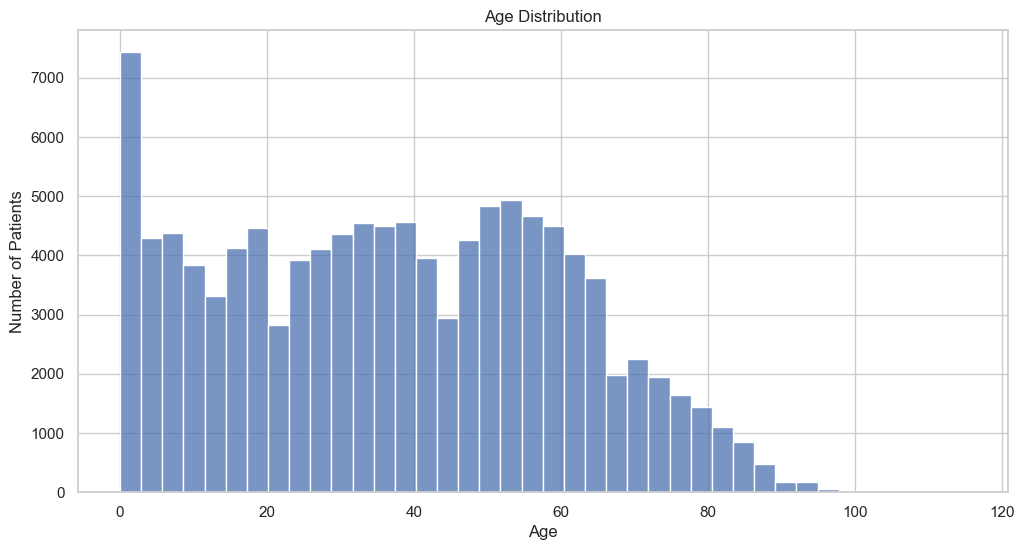

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(df['Age'], bins=40, kde=False)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.show()


### Check if patients with age = 0 have unrealistic medical conditions
We will examine how many age = 0 patients are marked as having hypertension, diabetes, alcoholism, or handicap.


In [14]:
def analyze_conditions_for_age_zero(df, age_col='Age', condition_cols=None):
    if condition_cols is None:
        condition_cols = ['Hipertension', 'Diabetes', 'Alcoholism', 'Handcap']
    
    # Filter patients with age = 0
    age_zero = df[df[age_col] == 0]
    
    # Count values (0/1) for each condition
    summary = {}
    for col in condition_cols:
        summary[col] = age_zero[col].value_counts().to_dict()
    
    return pd.DataFrame(summary).fillna(0).astype(int).T

# Use the function
analyze_conditions_for_age_zero(df)


,0,1
Hipertension,3539,0
Diabetes,3539,0
Alcoholism,3539,0
Handcap,3538,1


##### All 3,539 patients with age 0 have zero cases of hypertension, diabetes, or alcoholism, and only one case of handicap.  
##### This strongly supports that the age 0 values are valid entries representing infants or newborns, and not data entry errors.


## Rename columns to fix typos and improve clarity

Some column names contain misspellings or inconsistent formatting.  
We will rename them to make the dataset easier to work with.


In [15]:
#Define a function to clean column names and optionally convert binary columns to categorical
def clean_columns(df, convert_binary_to_categorical=False):
    # 1. Fix column names
    df = df.rename(columns={
        'Hipertension': 'Hypertension',
        'Handcap': 'Handicap',
        'No-show': 'No_show'
    })

    # 2. Convert PatientId and AppointmentID to string
    id_cols = ['PatientId', 'AppointmentID']
    for col in id_cols:
        if col in df.columns:
            df[col] = df[col].astype(str)

    # 3. Convert binary columns to Yes/No if needed
    if convert_binary_to_categorical:
        binary_map = {0: 'No', 1: 'Yes'}
        binary_cols = ['Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'SMS_received']
        for col in binary_cols:
            if col in df.columns:
                df[col] = df[col].map(binary_map)
        if 'No_show' in df.columns:
            df['No_show'] = df['No_show'].map({'No': 'Showed', 'Yes': 'No-show'})

    return df

df = clean_columns(df, convert_binary_to_categorical=True)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110526 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   PatientId       110526 non-null  object
 1   AppointmentID   110526 non-null  object
 2   Gender          110526 non-null  object
 3   ScheduledDay    110526 non-null  object
 4   AppointmentDay  110526 non-null  object
 5   Age             110526 non-null  int64 
 6   Neighbourhood   110526 non-null  object
 7   Scholarship     110526 non-null  object
 8   Hypertension    110526 non-null  object
 9   Diabetes        110526 non-null  object
 10  Alcoholism      110526 non-null  object
 11  Handicap        110526 non-null  int64 
 12  SMS_received    110526 non-null  object
 13  No_show         110526 non-null  object
dtypes: int64(2), object(12)
memory usage: 12.6+ MB


In [17]:
#show the level of handicap
df['Handicap'].value_counts()


Handicap
0    108285
1      2042
2       183
3        13
4         3
Name: count, dtype: int64

### Analyze the relationship between Handicap levels and No-show behavior

We want to check if the degree of disability (Handicap) affects the likelihood of a patient missing their appointment.  
We will calculate the percentage of no-shows for each Handicap level.


In [18]:
df.groupby('Handicap')['No_show'].value_counts(normalize=True)


Handicap  No_show
0         Showed     0.797645
          No-show    0.202355
1         Showed     0.820764
          No-show    0.179236
2         Showed     0.797814
          No-show    0.202186
3         Showed     0.769231
          No-show    0.230769
4         Showed     0.666667
          No-show    0.333333
Name: proportion, dtype: float64

**The no-show rate varies slightly across Handicap levels.** 
Patients with Handicap = 1 actually showed up more frequently than those with no disability.  
Higher handicap levels (3 and 4) show increased no-show rates, but these levels have very few cases and should be interpreted with caution.

We will keep the Handicap column as numeric for further modeling and analysis.


### Convert ScheduledDay and AppointmentDay columns to datetime format and create a new columns: Days_between & DayOfWeek

These columns are currently stored as strings.  
We will convert them to datetime so we can perform time-based calculations and extract useful date features.


In [19]:
# Convert datetime columns to date only (remove time and timezone)
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay']).dt.date
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay']).dt.date

# calculate new columns based on date-only format
df['Days_between'] = (pd.to_datetime(df['AppointmentDay']) - pd.to_datetime(df['ScheduledDay'])).dt.days
df = df[df['Days_between'] >= 0]

# calculate DayOfWeek and ScheduledHour using datetime 
df['DayOfWeek'] = pd.to_datetime(df['AppointmentDay']).dt.day_name()
df['ScheduledHour'] = pd.to_datetime(df['ScheduledDay']).dt.hour

# Show final DataFrame sample
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No_show,Days_between,DayOfWeek,ScheduledHour
0,29872500000000.0,5642903,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,No,Yes,No,No,0,No,Showed,0,Friday,0
1,558998000000000.0,5642503,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,No,No,No,No,0,No,Showed,0,Friday,0
2,4262960000000.0,5642549,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,No,No,No,No,0,No,Showed,0,Friday,0
3,867951000000.0,5642828,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,No,No,No,No,0,No,Showed,0,Friday,0
4,8841190000000.0,5642494,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,No,Yes,Yes,No,0,No,Showed,0,Friday,0


In [20]:
# Check types
print(df[['ScheduledDay', 'AppointmentDay']].dtypes)

# Check first few rows
df[['ScheduledDay', 'AppointmentDay']].head()


ScheduledDay      object
AppointmentDay    object
dtype: object


,ScheduledDay,AppointmentDay
0,2016-04-29,2016-04-29
1,2016-04-29,2016-04-29
2,2016-04-29,2016-04-29
3,2016-04-29,2016-04-29
4,2016-04-29,2016-04-29


In [21]:
# Count how many NaT (missing datetime values) exist
df[['ScheduledDay', 'AppointmentDay']].isna().sum()


ScheduledDay      0
AppointmentDay    0
dtype: int64

### Check summary statistics and unusual values in Days_between column


In [23]:
def check_days_between_summary(df, column='Days_between'):
    print("=== Summary Statistics ===")
    print(df[column].describe())
    print("\n=== Number of Negative Values ===")
    print((df[column] < 0).sum())
    print("\n=== Sample Rows with Negative Values ===")
    display(df[df[column] < 0].head())
check_days_between_summary(df)


=== Summary Statistics ===
count    110521.000000
mean         10.184345
std          15.255153
min           0.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: Days_between, dtype: float64

=== Number of Negative Values ===
0

=== Sample Rows with Negative Values ===


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No_show,Days_between,DayOfWeek,ScheduledHour


In [24]:
#Remove rows with negative Days_between values
df = df[df['Days_between'] >= 0]
df.shape


(110521, 17)

# 3-Exploratory data analysis (EDA)

### 1-3 Target Variable Distribution (No-show)



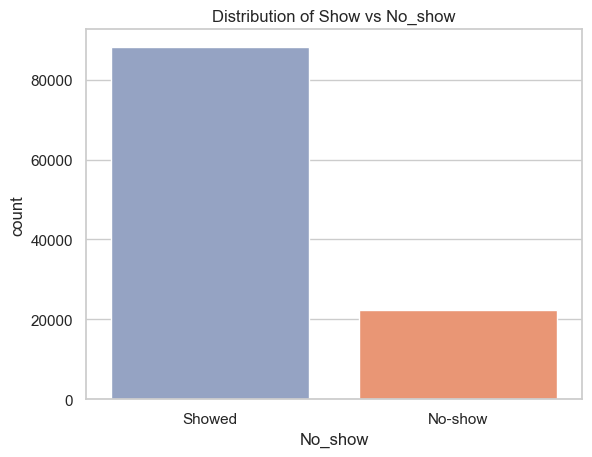

In [60]:
# Check how many patients showed up vs. missed their appointments
sns.countplot(x='No_show', data=df,hue='No_show',palette=['#8da0cb', '#fc8d62'])
plt.title('Distribution of Show vs No_show')
plt.show()

In [26]:
df['No_show'].value_counts(normalize=True)


No_show
Showed     0.798102
No-show    0.201898
Name: proportion, dtype: float64

##### About 80% of patients showed up, and 20% missed their appointments.
##### This confirms a class imbalance in the target variable.


### 2-3. Gender vs. No-show

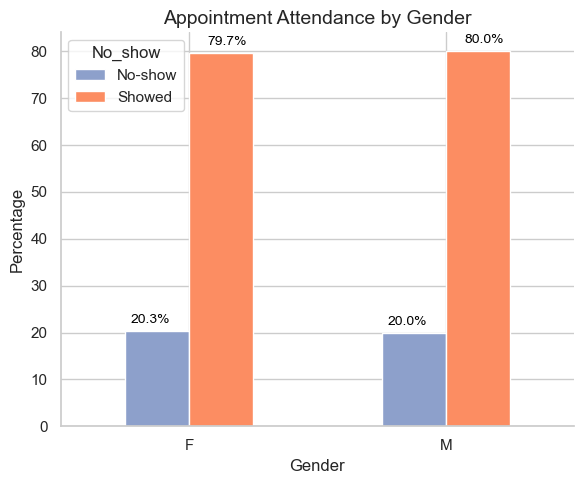

In [84]:
# Analyze if gender has any impact on missed appointments
# Create percentage table
gender_no_show = pd.crosstab(df['Gender'], df['No_show'], normalize='index') * 100

# Plot grouped bar chart
fig, ax = plt.subplots(figsize=(6, 5))
colors = ['#8da0cb', '#fc8d62']
gender_no_show.plot(kind='bar', ax=ax, color=colors)

# Add annotations
for i, row in enumerate(gender_no_show.values):
    for j, val in enumerate(row):
        ax.text(i + (j - 0.5) * 0.3, val + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=10, color='black')

# Styling
ax.set_title('Appointment Attendance by Gender', fontsize=14)
ax.set_ylabel('Percentage')
ax.set_xlabel('Gender')
ax.legend(title='No_show')
sns.despine()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


- **Female patients** had a no-show rate of approximately **20.3%**.
- **Male patients** had a no-show rate of around **20%**.
- Show-up rates are slightly higher among males.
- The difference is minor but may suggest gender-related attendance tendencies.



### 3-3. Day of the Week vs No_show



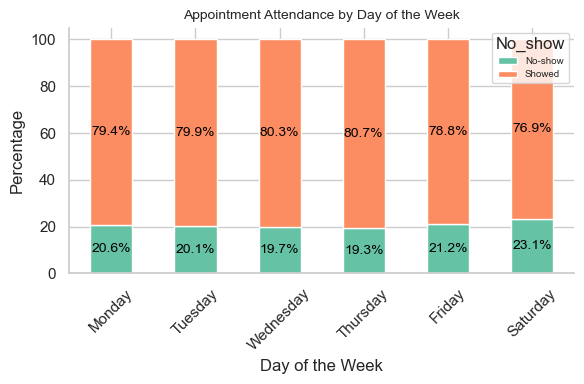

In [39]:
# Check attendance pattern by day of the week
# Create a clearer plot for DayOfWeek vs No_show with normalized percentages
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#66c2a5', '#fc8d62']  # Custom professional color palette

# Plot stacked bars
day_no_show.plot(kind='bar', stacked=True, ax=ax, color=colors)

# Add percentage annotations to each bar segment
for i, day in enumerate(day_no_show.index):
    total = 0
    for label in day_no_show.columns:
        value = day_no_show.loc[day, label]
        total += value
        ax.text(i, total - (value / 2), f'{value:.1f}%', ha='center', va='center', fontsize=10, color='black')

# Styling
ax.set_title('Appointment Attendance by Day of the Week', fontsize=10)
ax.set_ylabel('Percentage')
ax.set_xlabel('Day of the Week')
ax.legend(title='No_show', loc='upper right', fontsize=7)
ax.set_xticklabels(day_no_show.index, rotation=45)
sns.despine()
plt.tight_layout()
plt.show()



- **Saturday** had the lowest show-up rate at **76.9%**, followed by **Friday**.
- **Thursday** had the highest attendance rate at **80.7%**, followed closely by **Wednesday** and **Tuesday**.
- Attendance is generally stronger midweek and weaker around the weekend.
- Scheduling appointments midweek may help reduce no-shows.


### 4-3 Days Between vs No_show

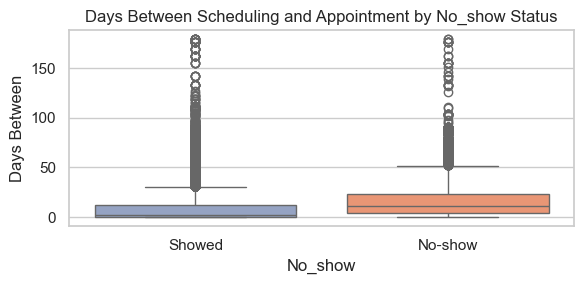

In [55]:
#لإhe Boxplot for Days_between vs No_show (clean and professional)
plt.figure(figsize=(6, 3))
sns.boxplot(x='No_show', y='Days_between',hue='No_show', data=df, palette=['#8da0cb', '#fc8d62'])

plt.title('Days Between Scheduling and Appointment by No_show Status', fontsize=12)
plt.xlabel('No_show')
plt.ylabel('Days Between')
plt.tight_layout()
plt.show()




- Patients who did not show up had a slightly **higher median number of waiting days**.
- The distribution for no-show cases shows more variation, including some long delays.
- Patients who showed up had shorter and more consistent scheduling intervals.
- Longer waiting times may contribute to missed appointments.


### 5-3 Age Distribution vs No_show Status

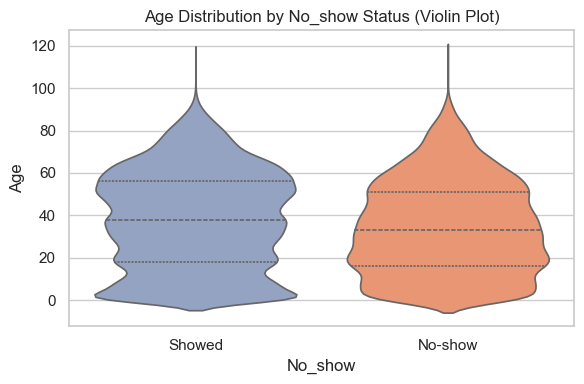

In [45]:
# Create a violin plot to show the distribution more clearly with density
plt.figure(figsize=(6, 4))
sns.violinplot(x='No_show', y='Age', hue='No_show', data=df, palette=['#8da0cb', '#fc8d62'], inner='quartile', legend=False)
plt.title('Age Distribution by No_show Status (Violin Plot)', fontsize=12)
plt.xlabel('No_show')
plt.ylabel('Age')
plt.tight_layout()
plt.show()




- The median age for patients who showed up is slightly higher than for those who missed their appointments.
- Most no-show cases are concentrated in the younger age ranges.
- The show-up group includes a wider age range, including more elderly patients.
- Younger patients appear to be more likely to skip appointments compared to older ones.


### 6-3 SMS_received vs No_show

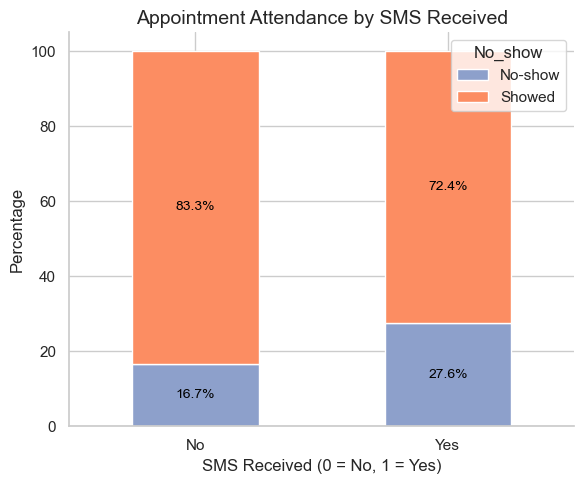

In [85]:
# Create a percentage-based bar chart for SMS_received vs No_show
sms_no_show = pd.crosstab(df['SMS_received'], df['No_show'], normalize='index') * 100

# Plot the bar chart
fig, ax = plt.subplots(figsize=(6, 5))
colors = ['#8da0cb', '#fc8d62']

sms_no_show.plot(kind='bar', stacked=True, ax=ax, color=colors)

# Annotate each segment with percentages
for i, sms in enumerate(sms_no_show.index):
    total = 0
    for label in sms_no_show.columns:
        value = sms_no_show.loc[sms, label]
        total += value
        ax.text(i, total - (value / 2), f'{value:.1f}%', ha='center', va='center', fontsize=10, color='black')

# Styling
ax.set_title('Appointment Attendance by SMS Received', fontsize=14)
ax.set_ylabel('Percentage')
ax.set_xlabel('SMS Received (0 = No, 1 = Yes)')
ax.legend(title='No_show', loc='upper right')
sns.despine()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


- Surprisingly, patients who did **not** receive an SMS reminder had a **higher show-up rate (~83%)**.
- Patients who **received** receive reminders were more likely to miss their appointments by **(27.6%)** which is higher than who not receive SM.
- This counterintuitive result suggests that SMS reminders alone may not be effective and that other variables could be influencing attendance.



### 7-3 Scholarship vs No_show

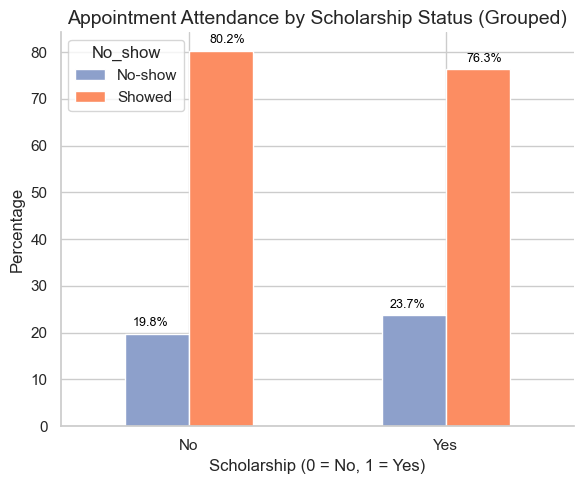

In [86]:
#Prepare data for grouped bar chart
scholar_grouped = df.groupby(['Scholarship', 'No_show']).size().unstack().fillna(0)

# Normalize to get percentage within each scholarship group
scholar_grouped_percent = scholar_grouped.div(scholar_grouped.sum(axis=1), axis=0) * 100

# Plot the grouped bar chart
fig, ax = plt.subplots(figsize=(6, 5))
scholar_grouped_percent.plot(kind='bar', ax=ax, color=['#8da0cb', '#fc8d62'])

# Annotate with percentage values
for i, row in enumerate(scholar_grouped_percent.values):
    for j, val in enumerate(row):
        ax.text(i + (j - 0.5) * 0.3, val + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

# Styling
ax.set_title('Appointment Attendance by Scholarship Status (Grouped)', fontsize=14)
ax.set_ylabel('Percentage')
ax.set_xlabel('Scholarship (0 = No, 1 = Yes)')
ax.legend(title='No_show')
sns.despine()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()




- Among patients without a scholarship, approximately **80.1%** showed up and **19.9%** missed their appointments.
- Among scholarship recipients, the show-up rate drops to **76.3%**, with a no-show rate of **23.7%**.
- This indicates a slight increase in missed appointments among those receiving financial aid.
-  Financial support alone may not be enough to improve attendance behavior.



### 8-3 Medical factores VS No_show

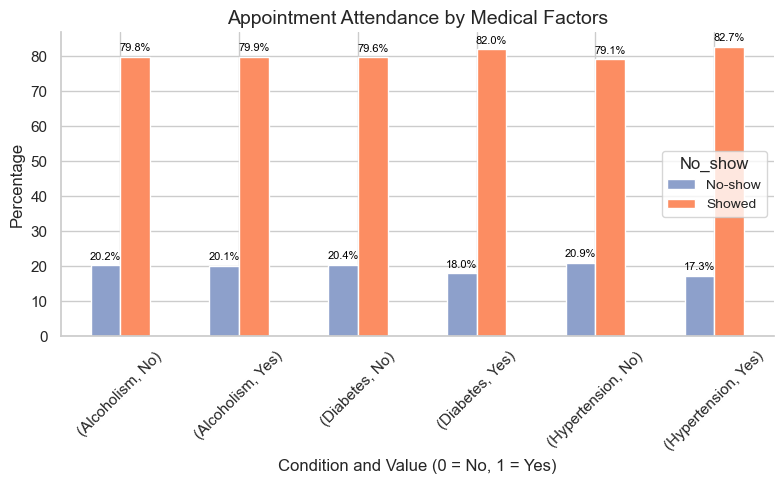

In [71]:
# Prepare data: select relevant columns (excluding Handicap)
medical_cols = ['Hypertension', 'Diabetes', 'Alcoholism']

# Melt the data to long format to plot all in one chart
df_melted = df.melt(id_vars='No_show', value_vars=medical_cols, var_name='Condition', value_name='Value')

# Group and normalize to get percentages for each condition/value/No_show
condition_grouped = df_melted.groupby(['Condition', 'Value', 'No_show']).size().unstack().fillna(0)
condition_percent = condition_grouped.div(condition_grouped.sum(axis=1), axis=0) * 100

# Plot as grouped bar chart for each condition
fig, ax = plt.subplots(figsize=(8, 5))
condition_percent.plot(kind='bar', ax=ax, color=['#8da0cb', '#fc8d62'])

# Annotate percentages
for i, row in enumerate(condition_percent.values):
    for j, val in enumerate(row):
        ax.text(i + (j - 0.5) * 0.25, val + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=8, color='black')

# Styling
ax.set_title('Appointment Attendance by Medical Factors', fontsize=14)
ax.set_ylabel('Percentage')
ax.set_xlabel('Condition and Value (0 = No, 1 = Yes)')
ax.legend(title='No_show',fontsize=10)
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()


- Patients **with** chronic conditions (value =yes) had **higher show-up rates** in all three categories.
- Patients with **Hypertension** or **Diabetes** had slightly higher no-show rates, around 20.4–20.9%.
- Patients with **Alcoholism** also showed a modest increase in missed appointments.
- patients with known health issues may feel a stronger commitment to attend their medical appointments.



### 8-3 Handicap vs No_show

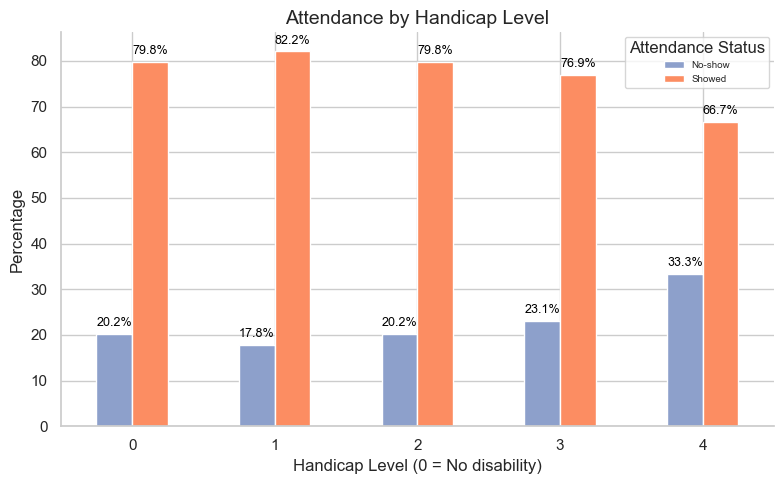

In [88]:
# Create percentage-based bar chart for Handicap vs No_show
handicap_percent = pd.crosstab(df['Handicap'], df['No_show'], normalize='index') * 100

# Plot grouped bar chart (best for multi-level categorical variable)
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#8da0cb', '#fc8d62']
handicap_percent.plot(kind='bar', ax=ax, color=colors)

# Annotate percentages
for i, row in enumerate(handicap_percent.values):
    for j, val in enumerate(row):
        ax.text(i + (j - 0.5) * 0.25, val + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

# Styling
ax.set_title('Attendance by Handicap Level', fontsize=14)
ax.set_ylabel('Percentage')
ax.set_xlabel('Handicap Level (0 = No disability)')
ax.legend(title='Attendance Status',fontsize=7)
plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.show()



- The majority of patients have  disability (level 4) show a higher no-show rate as **33.3%**.
- Patients with any level of disabilitmy (levels 1 ) consistently show **higher attendance rates**, ranging from **82%**.
- Although the number of patients with higher disability levels is small, the trend suggests they are more likely to attend appointments.
- This could indicate higher medical awareness or need for follow-up among disabled patients.
